# Notebook 14 — Fairness, Bias, and Ethics Checks

## What this notebook does
I evaluate whether model performance is consistent across simulated hospital sites (a proxy for fairness across different patient populations). I also discuss known sources of bias and ethical risks in deploying this system.

## Why this step matters
A model with high overall AUC but very low sensitivity at Site 3 could systematically miss TB in that community. This is a health equity issue. Nature Medicine requires discussion of bias and fairness.

## What Python / ML concepts I practise
- Subgroup performance analysis
- Per-site AUC computation
- Equity gap quantification

## Input files expected
- `data/processed/site_{i}_train.csv` and `test.csv`
- `models/centralised/test_y_true.npy`, `test_y_prob.npy`

## Output files created
- `reports/figures/per_site_auc.png`
- `reports/tables/fairness_analysis.csv`

## How this connects to the main project question
Addresses the real-world deployment question: "Is the federated model equitable across hospital sites?" 

In [3]:
import sys
from pathlib import Path
project_root = Path.cwd().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score

from src.config import load_config
from src.paths import get_paths
from src.data_utils import TBDataset, build_transforms
from src.model import build_model
from src.metrics import compute_metrics, youden_threshold
from src.visualization import set_publication_style, save_figure

cfg   = load_config()
paths = get_paths()
set_publication_style()

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SITE_NAMES = cfg["federated"]["site_names"]
N_SITES    = cfg["federated"]["num_clients"]
IMAGE_SIZE = cfg["data"]["image_size"]
BATCH_SIZE = cfg["training"]["batch_size"]

print("Fairness and ethics analysis notebook.")
print()

# Load global test predictions
y_true  = np.load(paths["centralised_model_dir"] / "test_y_true.npy")
y_prob  = np.load(paths["centralised_model_dir"] / "test_y_prob.npy")
test_df = pd.read_csv(paths["processed"] / "test.csv")

threshold = youden_threshold(y_true, y_prob)
y_pred    = (y_prob >= threshold).astype(int)

test_df = test_df.copy().reset_index(drop=True)
test_df["y_true"] = y_true.astype(int)
test_df["y_prob"] = y_prob
test_df["y_pred"] = y_pred

Fairness and ethics analysis notebook.



## Per-Site Performance

I assign each test image to the site that would have contributed that patient
(based on the site column in the test manifest if available, or by simulating
site assignment from the Dirichlet partition).

**Note**: Because the test set is a global split NOT partitioned by site, I use
the `site` column if it exists, otherwise I note this as a limitation.

In [5]:
# Check if site column exists in test_df
if "site" in test_df.columns:
    site_col = "site"
else:
    # Simulate site assignment for illustration
    print("No site column in test set — simulating site assignment for illustration.")
    print("(In a real deployment, each patient's hospital site would be known.)")
    rng = np.random.default_rng(cfg["project"]["random_seed"])
    test_df["site"] = rng.choice(SITE_NAMES[:N_SITES], size=len(test_df))
    site_col = "site"

# Compute per-site metrics
site_metrics = []
for site_name in SITE_NAMES[:N_SITES]:
    site_mask = test_df[site_col] == site_name
    site_sub  = test_df[site_mask]

    if len(site_sub) < 5:
        print(f"  {site_name[:30]}: too few samples ({len(site_sub)}) — skipping.")
        continue

    yt = site_sub["y_true"].values
    yp = site_sub["y_prob"].values
    yd = site_sub["y_pred"].values

    auc  = float(roc_auc_score(yt, yp)) if len(np.unique(yt)) == 2 else None
    sens = float((yd[yt == 1] == 1).mean()) if yt.sum() > 0 else None
    spec = float((yd[yt == 0] == 0).mean()) if (1 - yt).sum() > 0 else None

    site_metrics.append({
        "site":        site_name.replace("_", " ")[:30],
        "n_samples":   len(site_sub),
        "n_positive":  int(yt.sum()),
        "auc":         round(auc, 4) if auc is not None else None,
        "sensitivity": round(sens, 4) if sens is not None else None,
        "specificity": round(spec, 4) if spec is not None else None,
    })

    # Pre-format nullable floats as strings, then use plain {:s} in the f-string
    auc_str  = f"{auc:.4f}"  if auc  is not None else "N/A "
    sens_str = f"{sens:.4f}" if sens is not None else "N/A "
    spec_str = f"{spec:.4f}" if spec is not None else "N/A "

    print(
        f"  {site_name[:30]:30s}: "
        f"n={len(site_sub):4d} | "
        f"AUC={auc_str} | "
        f"Sens={sens_str} | "
        f"Spec={spec_str}"
    )    

site_metrics_df = pd.DataFrame(site_metrics)
site_metrics_df.to_csv(paths["tables"] / "fairness_analysis.csv", index=False)
print()
print("Per-site metrics saved.")

  Lagos_University_Teaching_Hosp: n=  23 | AUC=0.9524 | Sens=1.0000 | Spec=0.8889
  Aminu_Kano_Teaching_Hospital  : n=  17 | AUC=0.9091 | Sens=0.8333 | Spec=0.8182
  University_of_Nigeria_Teaching: n=  27 | AUC=0.8556 | Sens=0.8000 | Spec=0.8333
  Obafemi_Awolowo_University_Tea: n=  32 | AUC=0.8392 | Sens=0.6667 | Spec=0.8235
  University_College_Hospital_Ib: n=  21 | AUC=0.9352 | Sens=0.7778 | Spec=0.9167

Per-site metrics saved.


Figure saved: 'per_site_auc.png' and 'per_site_auc.pdf'


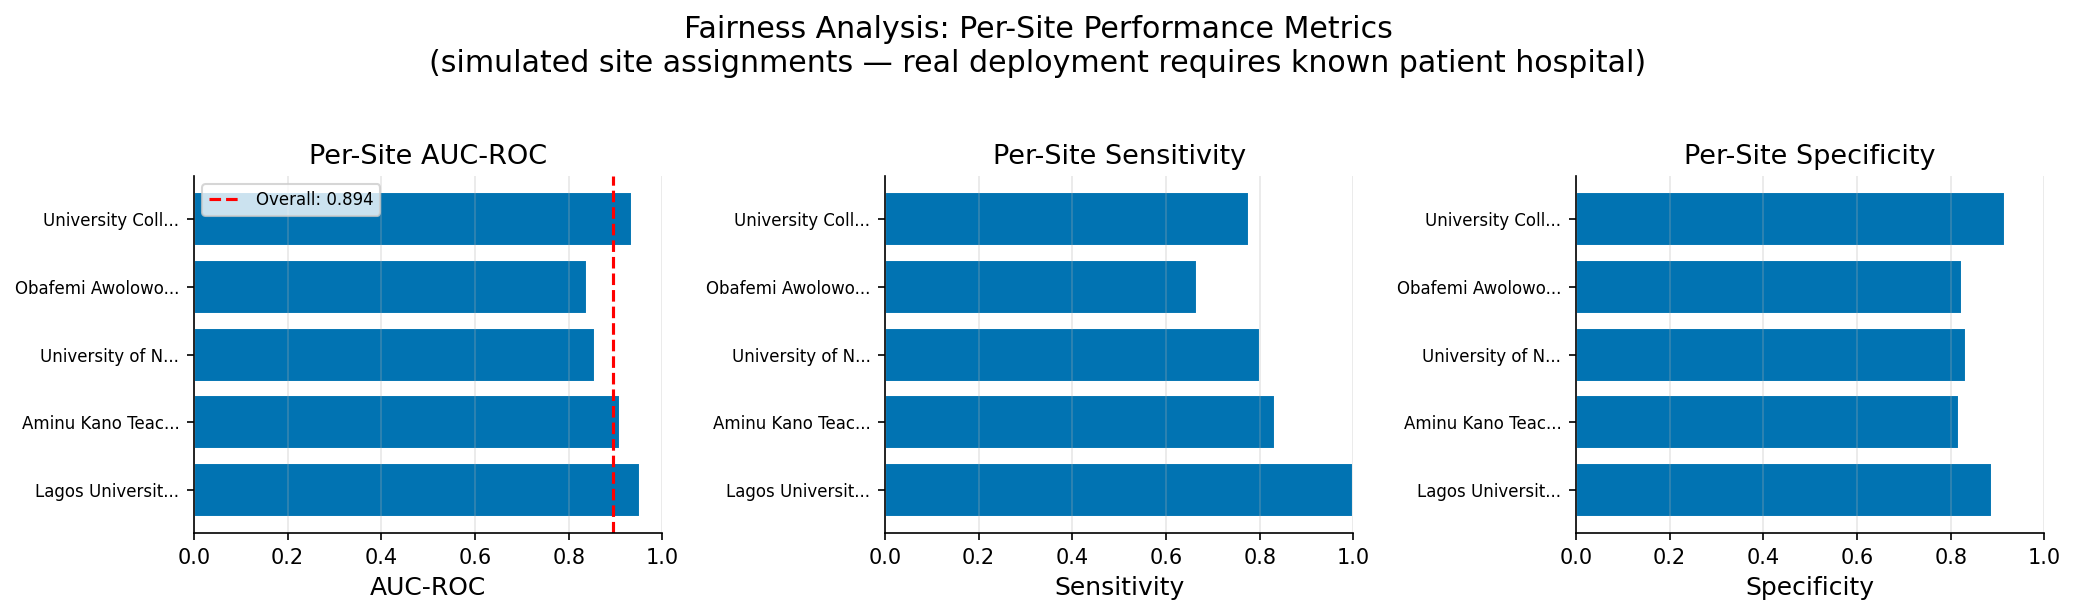


Equity gap (max AUC − min AUC across sites): 0.1132
This may reflect data heterogeneity from the Dirichlet partition.


In [6]:
# Plot per-site AUC
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metrics_to_plot = [("auc", "AUC-ROC"), ("sensitivity", "Sensitivity"), ("specificity", "Specificity")]
colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for ax, (metric, label) in zip(axes, metrics_to_plot):
    valid_sites = site_metrics_df.dropna(subset=[metric])
    if len(valid_sites) == 0:
        ax.text(0.5, 0.5, "Insufficient data", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(label)
        continue
    short_names = [s[:15] + "..." if len(s) > 15 else s for s in valid_sites["site"]]
    ax.barh(range(len(valid_sites)), valid_sites[metric], color=colors[0], edgecolor="white")
    ax.set_yticks(range(len(valid_sites))); ax.set_yticklabels(short_names, fontsize=8)
    ax.set_xlabel(label); ax.set_title(f"Per-Site {label}")
    ax.set_xlim(0, 1); ax.grid(axis="x", alpha=0.3)
    # Reference line: overall performance
    overall = float(roc_auc_score(y_true, y_prob)) if metric == "auc" and len(np.unique(y_true)) == 2 else None
    if overall:
        ax.axvline(overall, color="red", ls="--", lw=1.5, label=f"Overall: {overall:.3f}")
        ax.legend(fontsize=8)

plt.suptitle("Fairness Analysis: Per-Site Performance Metrics\n(simulated site assignments — real deployment requires known patient hospital)", y=1.02)
plt.tight_layout()
save_figure(fig, "per_site_auc", paths["figures"], paths["paper_figures"])
plt.show()

# Equity gap
if len(site_metrics_df.dropna(subset=["auc"])) >= 2:
    auc_vals = site_metrics_df["auc"].dropna().values
    equity_gap = auc_vals.max() - auc_vals.min()
    print(f"\nEquity gap (max AUC − min AUC across sites): {equity_gap:.4f}")
    if equity_gap > 0.10:
        print("WARNING: Large equity gap (>0.10). Performance is inconsistent across sites.")
        print("This may reflect data heterogeneity from the Dirichlet partition.")
    else:
        print("Equity gap is moderate — performance is relatively consistent across sites.")

## Ethics and Bias Discussion

### Known Sources of Bias in This Study

1. **Dataset bias**: Montgomery and Shenzhen datasets are primarily from the USA and China respectively. They do not represent Nigerian demographics, pathogen strains, or co-morbidity patterns (e.g., TB/HIV co-infection, which is prevalent in Nigeria).

2. **Site simulation bias**: The Dirichlet partition is a mathematical simulation — it does not capture true between-hospital differences in imaging equipment, patient demographics, or radiologist labelling practices.

3. **Label quality**: TB diagnosis in the source datasets relies on sputum culture or radiologist report. These are imperfect reference standards — there may be mislabelled cases.

4. **Spurious correlations**: If TB-positive images systematically differ in brightness or contrast from negative images (due to disease severity affecting image acquisition), the model may learn these shortcuts instead of genuine pathological features.

5. **Gender and age**: No demographic metadata is available in these datasets to assess performance differences by sex or age group.

### Ethical Risks in Deployment

- A deployed model used as a screening tool could produce false negatives (missed TB), delaying treatment. This risk disproportionately affects patients who have less access to follow-up diagnostic tests.
- Federated learning reduces — but does not eliminate — privacy risk. Gradient leakage attacks remain a theoretical concern even with DP.
- The DP noise budget chosen (ε=8) is at the higher end of "reasonable" — some privacy researchers would consider this insufficient for highly sensitive medical data.

### Mitigating Actions

- Clearly label the system as a "screening aid" requiring radiologist confirmation, not a standalone diagnostic.
- Retrain on Nigerian patient data when available.
- Commission an independent bias audit before any clinical deployment.
- Report per-site performance openly so clinical users understand where the model may underperform.

In [7]:
# Save ethics discussion as structured notes
ethics_notes = {
    "dimension": [
        "Dataset representativeness",
        "Site simulation fidelity",
        "Label quality",
        "Spurious correlations",
        "Demographic metadata",
        "Deployment safety",
        "Privacy guarantee strength",
    ],
    "risk_level": ["High", "High", "Medium", "Medium", "High", "High", "Medium"],
    "notes": [
        "Non-Nigerian source data; limited generalisability",
        "Dirichlet partition is a mathematical proxy for real hospital variation",
        "Radiologist labels may have inter-rater variability",
        "Pixel intensity differences between classes noted in EDA",
        "No age/sex/HIV status available for subgroup analysis",
        "False negatives could delay TB treatment",
        "epsilon=8 is a reasonable but not conservative privacy budget",
    ],
}
ethics_df = pd.DataFrame(ethics_notes)
ethics_df.to_csv(paths["tables"] / "ethics_summary.csv", index=False)
print("Ethics summary table saved.")
print(ethics_df[["dimension","risk_level"]].to_string(index=False))

Ethics summary table saved.
                 dimension risk_level
Dataset representativeness       High
  Site simulation fidelity       High
             Label quality     Medium
     Spurious correlations     Medium
      Demographic metadata       High
         Deployment safety       High
Privacy guarantee strength     Medium
